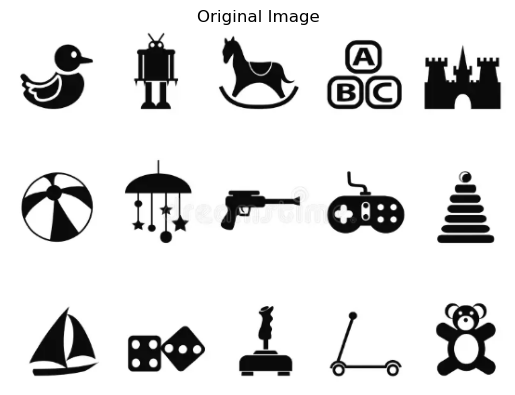

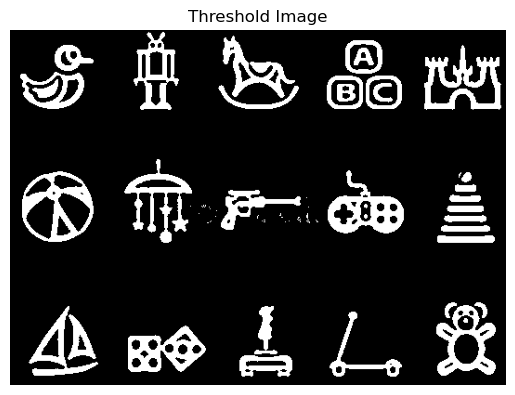

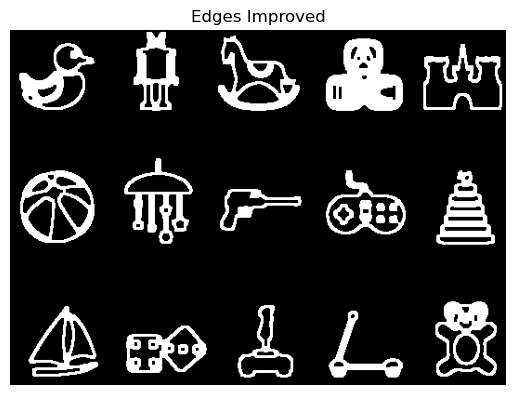

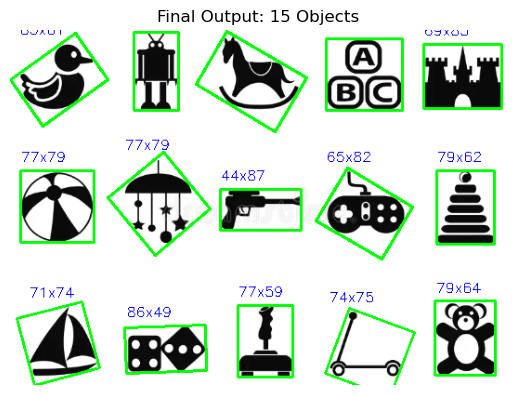

Total objects detected: 15
Latency: 0.008 seconds


In [5]:
import cv2
import numpy as np
import imutils
import time
from matplotlib import pyplot as plt

image_path = r"C:\Users\Janane S B\Downloads\input.jpg.png"
image = cv2.imread(image_path)

if image is None:
    raise ValueError("❌ Image not loaded")

orig = image.copy()

# Show original
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (9, 9), 0)

thresh = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2
)

plt.imshow(thresh, cmap='gray')
plt.title("Threshold Image")
plt.axis("off")
plt.show()

edged = cv2.Canny(blur, 30, 150)

kernel = np.ones((3,3), np.uint8)
edged = cv2.dilate(edged, kernel, iterations=2)
edged = cv2.erode(edged, kernel, iterations=1)

plt.imshow(edged, cmap='gray')
plt.title("Edges Improved")
plt.axis("off")
plt.show()

cnts = cv2.findContours(edged.copy(),
                        cv2.RETR_EXTERNAL,
                        cv2.CHAIN_APPROX_SIMPLE)

cnts = imutils.grab_contours(cnts)

object_count = 0
start_time = time.time()

for c in cnts:
    if cv2.contourArea(c) < 20:
        continue

    object_count += 1

    rect = cv2.minAreaRect(c)
    box = cv2.boxPoints(rect)
    box = np.intp(box)

    cv2.drawContours(image, [box], -1, (0, 255, 0), 2)

    w, h = rect[1]
    x, y, bw, bh = cv2.boundingRect(c)

    label = f"{int(w)}x{int(h)}"
    cv2.putText(image, label,
                (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 0), 1)

end_time = time.time()
latency = end_time - start_time

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title(f"Final Output: {object_count} Objects")
plt.axis("off")
plt.show()

print(f"Total objects detected: {object_count}")
print(f"Latency: {latency:.3f} seconds")